# The resource-consumer NP model with odeint

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

## Analytical solution
The limited growth model
$$\frac{dN}{dt}=-k NP$$
$$\frac{dP}{dt}=k NP$$
has the analytical solution
\begin{align*}
P+N= & P_{0}+N_{0}\\
P(t)= & P_{0}\frac{P_{0}+N_{0}}{P_{0}+N_{0}e^{-k'\left(P_{0}+N_{0}\right)t}}
\end{align*}

We will be assisted by AI to plot the analytical solution using the following parameters:
* Time axis in days, from 0 to 20 days
* $k'=0.1$ d$^{-1}$; $P_{0}=0.1$ mmol N m$^{-3}$ and $N_{0}=5$ mmol N m$^{-3}$

We will answer the following questions (adding plots where needed)
1. Why are the curves identical in shape?
2. What happens when you change the value of the uptake parameter? Think about it as the percentage of food consumed per day.
3. What happens if the initial biomass of phytoplankton is close to the amount of resource available? How does the shape of the curve change?

## Numerical solution
The code below calculates the right-hand-side of the dynamics, as we read it straight from the equations. The parameter $k$, the uptake rate, is an input to the function, together with time and the state of the system, the current values of $N$ and $P$.

In [2]:
# function that returns the right hand side of the system dynamics
def model(state,t,k):
    N,P = state
    Ndot = -k * N * P
    Pdot =  k * N * P
    return np.array([Ndot,Pdot])

Set the initial conditions, the time axis and solve the ODE

In [3]:
# initial conditions 
K = 0.1 # d-1
N0 = 5. # mmol N/m3
P0 = 0.1 # mmol N/m3
state0 = np.array([N0,P0])

# 100 time points in the interval 0-20 days
t = np.linspace(0,20,num=100)

# solve ODE using odeint (remember that args is a tuple)
y = odeint(model,state0,t,args=(K,))

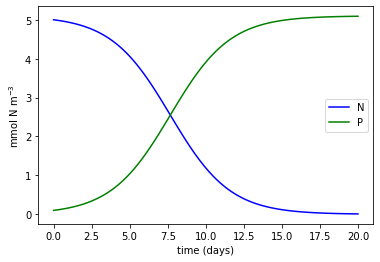

In [9]:
# plot the resulting time series
plt.plot(t,y[:,0],'b',label='N')
plt.plot(t,y[:,1],'g',label='P')
plt.xlabel('time (days)')
plt.ylabel('mmol N m$^{-3}$')
plt.legend()
plt.show()

# Exercise
1. Write a new model to simulate the nutrient-phytoplankton-detritus system (NPD). Include a detritus variable D that is produced from the mortality of phytoplankton and it is remineralized as a nutrient. This will involve adding 2 new parameters: the mortality rate (phytoplankton lysis) and the remineralization rate.

We can ask the AI to help us writing the equations using latex, as done above.

2. Write the code to solve the new model using odeint and propose some reasonable values for the parameters that give a realistic solution